<a href="https://colab.research.google.com/github/raisauw/demodua/blob/main/2311102205_2311102233_VISKOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap ini menginstall library Roboflow ke environment Colab

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


Tahap ini dicopy langsung dari Roboflow untuk login dengan API key dan ambil
dataset

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="EFxXfM2lrYpBjPy6jKFU")
project = rf.workspace("raifankas-workspace").project("trash-eeqam-8hklk")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to trash-1 in folder:: 100%|██████████| 882/882 [00:00<00:00, 3371.48it/s]


Import library untuk operasi file, lalu list semua file dan folder di dalam folder dataset, tampilkan struktur lengkap beserta contoh 3 file pertama di setiap folder

In [3]:
import os

# cek folder
dataset_location = dataset.location
print("Dataset location:", dataset_location)
print("\nFolder contents:")
for item in os.listdir(dataset_location):
    print(f"  - {item}")

# cek structure
print("\nDetailed structure:")
for root, dirs, files in os.walk(dataset_location):
    level = root.replace(dataset_location, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # show 3 file pertama
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... dan {len(files) - 3} file lainnya')

Dataset location: /content/trash-1

Folder contents:
  - README.roboflow.txt
  - train
  - valid
  - test
  - README.dataset.txt

Detailed structure:
trash-1/
  README.roboflow.txt
  README.dataset.txt
  train/
    Plastik/
      plastic_cup-98-Copy_png.rf.df888c4b3af30a878a849fd1cf77734d.jpg
      plastic_cup-178-_png.rf.ac27a797ea5a71719d745515fe639788.jpg
      sedotan-46-_png.rf.fcc5adc49ab01d366c84d158c5ff2eb4.jpg
      ... dan 218 file lainnya
    Logam/
      metal299_jpg.rf.b2b0a5febdda4744cae0333da04d0a16.jpg
      metal254_jpg.rf.b5bc55534490e67521e50e22b43ece50.jpg
      R_1927_jpg.rf.8b7f9ad617d1758488fa7ced5cd94955.jpg
      ... dan 64 file lainnya
    Organik/
      daun-50-_jpg.rf.02f3854827c1109ee1eeca0a43931a23.jpg
      daun-38-_jpg.rf.550163fb3511384fd816ec66fa76cfcc.jpg
      daun-44-_jpg.rf.b23fd9565eeebbf90f8bd11e9eb5b2ca.jpg
      ... dan 85 file lainnya
    Kaca/
      glass-cup-80-_png.rf.1b262754336b0c50937fd4ca857959db.jpg
      R_5313_jpg.rf.ad0087c6aa67d272

Load gambar dari folder, Set ukuran gambar target (224×224 piksel) dan jumlah gambar per batch saat training (32 gambar sekaligus). Setelah itu, definisikan path ke masing-masing folder train, validasi, dan test. Normalisasi setiap nilai piksel (0–255) dibagi 255  menjadi rentang 0-1. Load gambar dari folder train, resize otomatis ke 224×224 shuffle=True agar urutan gambar diacak tiap epoch kecuali val & test

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_PATH = '/content/trash-1/train'
VAL_PATH   = '/content/trash-1/valid'
TEST_PATH  = '/content/trash-1/test'

# Normalisasi pixel 0-255 to 0-1
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Kelas:", train_generator.class_indices)
print(f"Train: {train_generator.samples} gambar")
print(f"Validation: {val_generator.samples} gambar")
print(f"Test: {test_generator.samples} gambar")

Found 617 images belonging to 5 classes.
Found 176 images belonging to 5 classes.
Found 87 images belonging to 5 classes.
Kelas: {'Kaca': 0, 'Kertas': 1, 'Logam': 2, 'Organik': 3, 'Plastik': 4}
Train: 617 gambar
Validation: 176 gambar
Test: 87 gambar


Import MobileNetV2, load MobileNetV2 yang sudah dilatih pada gambar ImageNet, buang head klasifikasinya. Setelah itu, freeze layer MobileNetV2. MobileNetV2 sebagai feature extractor, ubah output 7x7x1280 menjadi vektor 1280, layer fully connected, 128 neuron, matikan 30% neuron secara random saat training, output 5 kelas, softmax = probabilitas

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' # transfer learning
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 kelas
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training 20 epoch, metrik accuracy dipantau saat training, pantau performa di data validasi tiap epoch, hasil tiap epoch disimpan di history

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6985 - loss: 0.8144 - val_accuracy: 0.8864 - val_loss: 0.3311
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9449 - loss: 0.2234 - val_accuracy: 0.9148 - val_loss: 0.2517
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9660 - loss: 0.1243 - val_accuracy: 0.9261 - val_loss: 0.2211
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9838 - loss: 0.0836 - val_accuracy: 0.9205 - val_loss: 0.2546
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9838 - loss: 0.0647 - val_accuracy: 0.9148 - val_loss: 0.2729
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9951 - loss: 0.0393 - val_accuracy: 0.9091 - val_loss: 0.2565
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 1.0000 - loss: 0.0317 - val_accuracy: 0.9148 - val_loss: 0.2592
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9935 - loss: 0.0323 - val_accuracy: 0.9148 - val_loss:

evaluasi

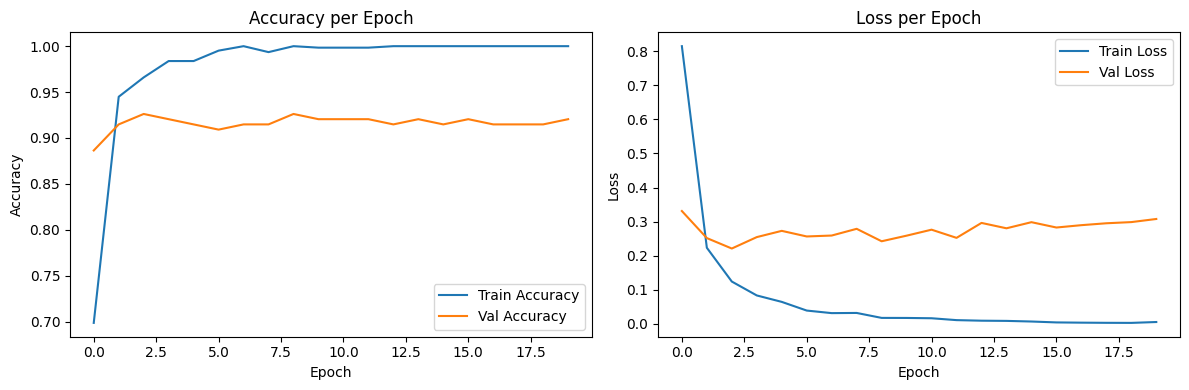

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 933ms/step - accuracy: 0.9425 - loss: 0.1935

Test Accuracy: 94.25%
Test Loss: 0.1935
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Classification Report:
              precision    recall  f1-score   support

        Kaca       0.90      0.90      0.90        10
      Kertas       1.00      0.96      0.98        24
       Logam       0.90      1.00      0.95         9
     Organik       1.00      0.92      0.96        12
     Plastik       0.91      0.94      0.92        32

    accuracy                           0.94        87
   macro avg       0.94      0.94      0.94        87
weighted avg       0.94      0.94      0.94        87



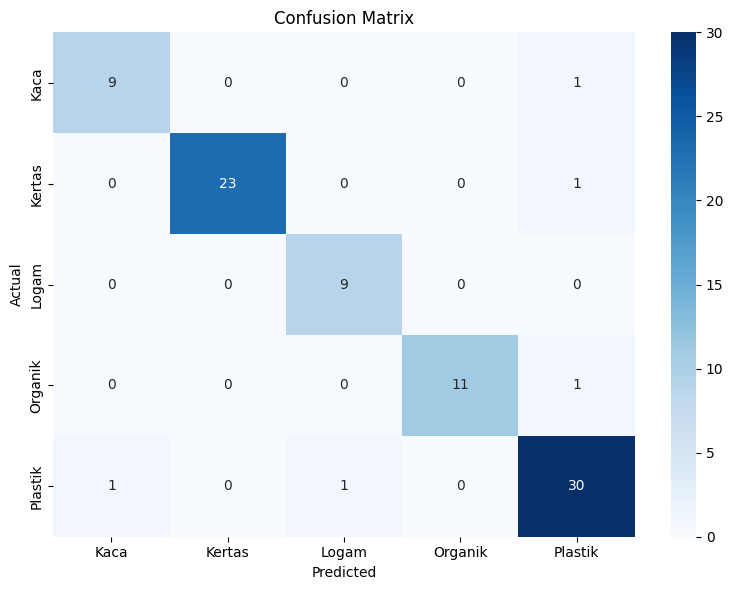

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

loss, acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()